In [ ]:
!pip install simpy scipy numpy pandas matplotlib seaborn plotly gdown -q

In [ ]:
import os, gdown

import simpy
import random
import numpy as np
from dataclasses import dataclass, field
from typing import List, Optional
from scipy import stats as sp_stats

import json, os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
FOLDER_ID = '1ppG7tIYzghT4Bf0KO6dh9jDP5B11143v'
os.makedirs('logs', exist_ok=True)

gdown.download_folder(
    id=FOLDER_ID,
    output='logs',
    quiet=False,
    use_cookies=False
)

print('\nArquivos baixados:')
for f in sorted(os.listdir('logs')):
    print(f'  {f}')

Retrieving folder contents


Processing file 1i_LYxMh5tLg4ep_NzI4zIux4PRk5ZAkL capture_rudp_scenarioA.csv
Processing file 1fGq4s7HAdg7MakCxcOCbdNoLABu6gOnn capture_rudp_scenarioB.csv
Processing file 1CcULs4DCqyk2TuPv6uq8k3JNS35hLmwI capture_rudp_scenarioC.pcap
Processing file 1d5fMOYS0xvEqNvzWM11Efos7DVJL9rj2 capture_tcp_scenarioA.csv
Processing file 1APxlUi7jvx2LWLHwziBEFxJaPqbclXwW capture_tcp_scenarioA.pcap
Processing file 1lOsSWtiIy8nHIQWR8xvoP7Nui3eM6gRH capture_tcp_scenarioB.csv
Processing file 1--TGwIWP8IQtq4Axv7vHqQLju7PXlm7h capture_tcp_scenarioB.pcap
Processing file 1ynkYXUSkiggAl6V8GVZT4Iid_O5OK6jZ capture_tcp_scenarioC.csv
Processing file 1z1cJPqxcvGfOtedwDDLB9LT6LtdkmDy3 capture_tcp_scenarioC.pcap
Processing file 1TMFqbxxeKXvXvknahKRcrYulGEBB4KSx results_rudp_scenarioA.json
Processing file 1YnxXoTX0yat2Pej61fEIGwSOoDn0wBz- results_rudp_scenarioB.json
Processing file 1-LRSrcRQzZrrFVsotxRf8LvKuojSXRDZ results_rudp_scenarioC.json
Processing file 1tZpfz7Tf7jmNdU8Y_ntU-hpMP5CkVnxO results_tcp_scenarioA.jso

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1i_LYxMh5tLg4ep_NzI4zIux4PRk5ZAkL
To: /content/logs/capture_rudp_scenarioA.csv
100%|██████████| 4.49k/4.49k [00:00<00:00, 9.83MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGq4s7HAdg7MakCxcOCbdNoLABu6gOnn
To: /content/logs/capture_rudp_scenarioB.csv
100%|██████████| 4.57k/4.57k [00:00<00:00, 10.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CcULs4DCqyk2TuPv6uq8k3JNS35hLmwI
To: /content/logs/capture_rudp_scenarioC.pcap
100%|██████████| 6.81k/6.81k [00:00<00:00, 15.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1d5fMOYS0xvEqNvzWM11Efos7DVJL9rj2
To: /content/logs/capture_tcp_scenarioA.csv
100%|██████████| 546k/546k [00:00<00:00, 99.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1APxlUi7jvx2LWLHwziBEFxJaPqbclXwW
To: /content/logs/capture_tcp_scenarioA.pcap
100%|██████████| 31.7M/31.7M [


Arquivos baixados:
  capture_rudp_scenarioA.csv
  capture_rudp_scenarioB.csv
  capture_rudp_scenarioC.pcap
  capture_tcp_scenarioA.csv
  capture_tcp_scenarioA.pcap
  capture_tcp_scenarioB.csv
  capture_tcp_scenarioB.pcap
  capture_tcp_scenarioC.csv
  capture_tcp_scenarioC.pcap
  results_rudp_scenarioA.json
  results_rudp_scenarioB.json
  results_rudp_scenarioC.json
  results_tcp_scenarioA.json
  results_tcp_scenarioB.json
  results_tcp_scenarioC.json
  server_rudp_A.log
  server_rudp_B.log
  server_rudp_C.log
  server_tcp_A.log
  server_tcp_B.log
  server_tcp_C.log



Download completed


#Simulador

In [ ]:
CHUNK_SIZE   = 4096
WINDOW_SIZE  = 16
TIMEOUT_MIN  = 0.3
TIMEOUT_MAX  = 1.5
ALPHA_EWMA   = 0.25

# Parâmetros calibrados com dados reais da Fase 1
SCENARIOS = {
    "A": {"delay_mean": 0.005, "delay_std": 0.0005, "loss_rate": 0.000},
    "B": {"delay_mean": 0.025, "delay_std": 0.003,  "loss_rate": 0.02},
    "C": {"delay_mean": 0.050, "delay_std": 0.006,  "loss_rate": 0.08},
}

@dataclass
class SimResult:
    scenario:        str
    file_size_mb:    float
    elapsed:         float
    throughput_kbps: float
    retransmissions: int
    packets_sent:    int
    packets_data:    int
    packets_ack:     int
    rtt_samples:     List[float] = field(default_factory=list)
    rtt_mean:        float = 0.0
    rtt_std:         float = 0.0
    efficiency:      float = 0.0
    window_size:     int   = WINDOW_SIZE
    loss_rate:       float = 0.0


class RUDPSimulator:
    """
    Simulador GBN com pipeline real.

    Arquitetura:
      - _gbn_sender: loop principal que mantém a janela cheia e detecta timeout
      - _send_and_ack: processo por pacote que simula RTT e retorna ACK via evento
      - base, next_seq: ponteiros da janela deslizante
      - ack_store: dicionário seq -> evento SimPy para sincronização
    """

    def __init__(self, file_size_bytes, delay_mean, delay_std,
                 loss_rate, window_size=WINDOW_SIZE,
                 jitter_factor=1.0, seed=None):

        self.file_size    = file_size_bytes
        self.delay_mean   = delay_mean
        self.delay_std    = delay_std * jitter_factor
        self.loss_rate    = loss_rate          # perda END-TO-END por pacote
        self.window_size  = window_size
        self.total_chunks = (file_size_bytes + CHUNK_SIZE - 1) // CHUNK_SIZE

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        # Estado GBN
        self.base         = 0
        self.next_seq     = 0
        self.retrans      = 0
        self.pkts_sent    = 0   # total de transmissões (originais + retrans)
        self.pkts_data    = 0   # pacotes DATA originais enviados
        self.pkts_ack     = 0   # ACKs recebidos com sucesso
        self.rtt_samples  = []
        self.rtt_avg      = delay_mean * 2 + 0.001

        self.env          = simpy.Environment()
        # ack_store[seq] = SimPy Event que é acionado quando ACK chega
        self.ack_store    = {}

    def _rtt_sample(self):
        """Amostra de RTT (ida + volta) com distribuição normal."""
        d = max(np.random.normal(self.delay_mean, self.delay_std), 0.001)
        return d * 2   # RTT = ida + volta

    def _packet_lost(self):
        """Perda end-to-end por pacote (modelo de Bernoulli)."""
        return random.random() < self.loss_rate

    def _update_rtt(self, sample):
        if sample < TIMEOUT_MAX:
            self.rtt_avg = (1 - ALPHA_EWMA) * self.rtt_avg + ALPHA_EWMA * sample
            self.rtt_avg = min(self.rtt_avg, TIMEOUT_MAX / 2)
            self.rtt_samples.append(sample)

    def _timeout(self):
        return min(max(2.0 * self.rtt_avg, TIMEOUT_MIN), TIMEOUT_MAX)

    def _send_and_ack(self, seq):
        """
        Processo SimPy por pacote:
        1. Aguarda o RTT (simula transmissão + propagação + ACK de volta)
        2. Se não perdido, aciona o evento de ACK no ack_store
        """
        send_time = self.env.now
        self.pkts_sent += 1

        rtt = self._rtt_sample()
        yield self.env.timeout(rtt)

        # Verifica perda end-to-end
        if self._packet_lost():
            return   # pacote ou ACK perdido — sem acionamento

        # ACK chegou com sucesso
        self._update_rtt(self.env.now - send_time)
        self.pkts_ack += 1

        # Aciona evento se ainda relevante (seq ainda dentro da janela)
        if seq in self.ack_store and not self.ack_store[seq].triggered:
            self.ack_store[seq].succeed(value=seq)

    def _gbn_sender(self):
        """
        Loop principal GBN:
        - Preenche a janela com processos _send_and_ack paralelos
        - Aguarda o primeiro ACK da janela (evento do menor seq pendente)
        - Se timeout → retransmite janela inteira (Go-Back-N)
        """
        while self.base < self.total_chunks:

            # Envia todos os pacotes que cabem na janela
            while self.next_seq < min(self.base + self.window_size,
                                      self.total_chunks):
                seq = self.next_seq
                if seq not in self.ack_store or self.ack_store[seq].triggered:
                    self.ack_store[seq] = self.env.event()
                    self.pkts_data += 1
                    self.env.process(self._send_and_ack(seq))
                self.next_seq += 1

            # Aguarda ACK do pacote base (menor seq sem confirmação)
            base_evt    = self.ack_store.get(self.base)
            timeout_val = self._timeout()
            base_antes  = self.base

            if base_evt is None or base_evt.triggered:
                # ACK já chegou antes de verificarmos
                self.base     += 1
                self.next_seq  = max(self.next_seq, self.base)
                continue

            # Espera ACK ou timeout
            resultado = yield base_evt | self.env.timeout(timeout_val)

            if base_evt in resultado:
                # ACK recebido — avança base
                self.base     += 1
                self.next_seq  = max(self.next_seq, self.base)
            else:
                # Timeout — Go-Back-N: retransmite janela inteira
                pkts_retrans   = self.next_seq - self.base
                self.retrans  += pkts_retrans
                # Cancela eventos pendentes e retransmite
                for s in range(self.base, self.next_seq):
                    self.ack_store[s] = self.env.event()
                    self.pkts_sent   += 1
                    self.env.process(self._send_and_ack(s))
                # next_seq não volta — apenas re-enviamos, mantendo a janela

    def run(self):
        self.env.process(self._gbn_sender())
        # Roda até todos os chunks serem confirmados
        self.env.run(until=self.env.process(self._wait_done()))

        elapsed         = self.env.now
        throughput_kbps = (self.file_size / elapsed) / 1024 if elapsed > 0 else 0
        rtt_arr         = np.array(self.rtt_samples) if self.rtt_samples else np.array([0.0])
        total_pkts      = self.pkts_data + self.pkts_ack
        efficiency      = self.pkts_data / total_pkts if total_pkts > 0 else 0

        return SimResult(
            scenario        = "",
            file_size_mb    = self.file_size / (1024 * 1024),
            elapsed         = elapsed,
            throughput_kbps = throughput_kbps,
            retransmissions = self.retrans,
            packets_sent    = self.pkts_sent,
            packets_data    = self.pkts_data,
            packets_ack     = self.pkts_ack,
            rtt_samples     = self.rtt_samples,
            rtt_mean        = float(rtt_arr.mean()),
            rtt_std         = float(rtt_arr.std()),
            efficiency      = efficiency,
            window_size     = self.window_size,
            loss_rate       = self.loss_rate,
        )

    def _wait_done(self):
        """Processo auxiliar que espera base chegar ao total."""
        while self.base < self.total_chunks:
            yield self.env.timeout(0.001)


# ── Funções auxiliares ────────────────────────────────────────────────────────

def run_scenario(scenario_name, file_size_bytes, n_runs=30,
                 window_size=WINDOW_SIZE, jitter_factor=1.0,
                 loss_override=None):
    params = SCENARIOS[scenario_name].copy()
    if loss_override is not None:
        params["loss_rate"] = loss_override
    results = []
    for i in range(n_runs):
        sim = RUDPSimulator(
            file_size_bytes = file_size_bytes,
            delay_mean      = params["delay_mean"],
            delay_std       = params["delay_std"],
            loss_rate       = params["loss_rate"],
            window_size     = window_size,
            jitter_factor   = jitter_factor,
            seed            = i * 42 + hash(scenario_name) % 1000,
        )
        r           = sim.run()
        r.scenario  = scenario_name
        r.loss_rate = params["loss_rate"]
        results.append(r)
    return results

def ci95(arr):
    arr = np.array(arr)
    n   = len(arr)
    if n < 2: return 0.0
    return sp_stats.t.ppf(0.975, df=n-1) * arr.std(ddof=1) / np.sqrt(n)

def summarize(results):
    tp  = [r.throughput_kbps  for r in results]
    el  = [r.elapsed          for r in results]
    rt  = [r.retransmissions  for r in results]
    rtt = [r.rtt_mean         for r in results]
    eff = [r.efficiency       for r in results]
    return {
        "n":               len(results),
        "throughput_mean": np.mean(tp),
        "throughput_ci95": ci95(tp),
        "elapsed_mean":    np.mean(el),
        "elapsed_ci95":    ci95(el),
        "retrans_mean":    np.mean(rt),
        "retrans_ci95":    ci95(rt),
        "rtt_mean":        np.mean(rtt),
        "rtt_ci95":        ci95(rtt),
        "efficiency_mean": np.mean(eff),
        "efficiency_ci95": ci95(eff),
    }

In [ ]:


def load_real_results():
    rows = []
    for scenario in ['A', 'B', 'C']:
        for proto in ['tcp', 'rudp']:
            path = os.path.join('logs', f'results_{proto}_scenario{scenario}.json')
            if not os.path.exists(path):
                print(f'[AVISO] {path} não encontrado')
                continue
            with open(path) as f:
                runs = json.load(f)
            for r in runs:
                rows.append({
                    'protocol':        r.get('protocol', proto.upper()),
                    'scenario':        scenario,
                    'run':             r.get('run', 1),
                    'elapsed':         r.get('elapsed', 0),
                    'throughput_kbps': r.get('throughput_kbps', 0),
                    'retransmissions': r.get('retransmissions', 0),
                })
    return pd.DataFrame(rows)

df_real = load_real_results()
df_rudp = df_real[df_real.protocol == 'R-UDP'].copy()
print(f'✓ {len(df_real)} registros reais carregados')
print(df_real.groupby(['protocol','scenario'])['throughput_kbps'].mean().round(1))

✓ 180 registros reais carregados
protocol  scenario
R-UDP     A            5112.6
          B             411.2
          C             108.4
TCP       A           23154.4
          B             619.4
          C              65.0
Name: throughput_kbps, dtype: float64


#Tarefa 1 - Modelagem de Atraso


In [ ]:
print("Executando Tarefa 1 — Modelagem de Atraso...")

FILE_1MB = 1 * 1024 * 1024
N_RUNS   = 30

# Coleta amostras de RTT do simulador
rtt_stats = {}
for sc in ['A', 'B', 'C']:
    results = run_scenario(sc, FILE_1MB, n_runs=N_RUNS)
    todas   = []
    for r in results:
        todas.extend(r.rtt_samples)
    arr = np.array(todas) * 1000  # ms
    rtt_stats[sc] = {
        'mean':     arr.mean(),
        'std':      arr.std(),
        'esperado': SCENARIOS[sc]['delay_mean'] * 2 * 1000,
    }

# Gráfico de barras comparando RTT esperado vs simulado
cenarios  = ['A', 'B', 'C']
labels_sc = ['Cenário A\n(0% / 10ms)', 'Cenário B\n(10% / 50ms)', 'Cenário C\n(20% / 100ms)']
esperados = [rtt_stats[sc]['esperado'] for sc in cenarios]
simulados = [rtt_stats[sc]['mean']     for sc in cenarios]
desvios   = [rtt_stats[sc]['std']      for sc in cenarios]

x     = np.arange(len(cenarios))
width = 0.35

print("\n✓ Tarefa 1 concluída")

Executando Tarefa 1 — Modelagem de Atraso...

✓ Tarefa 1 concluída


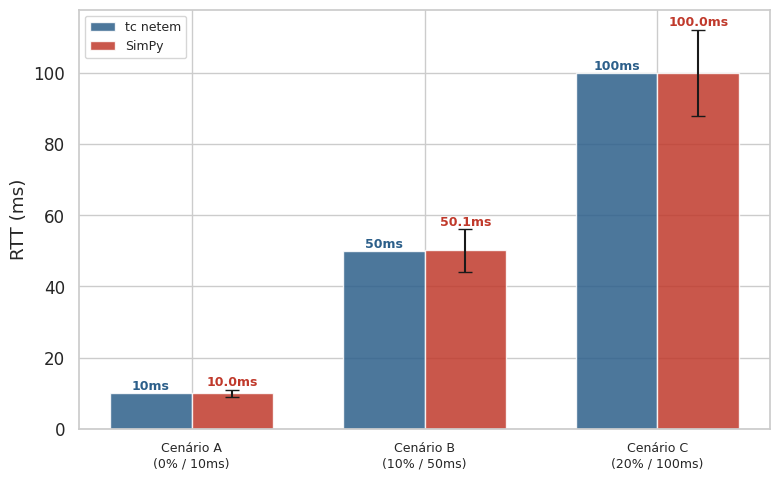

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, esperados, width,
               label='tc netem',
               color='#2C5F8A', alpha=0.85)
bars2 = ax.bar(x + width/2, simulados, width,
               yerr=desvios, capsize=5,
               label='SimPy',
               color='#C0392B', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels_sc, fontsize=9)
ax.set_ylabel('RTT (ms)')
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

for bar, val in zip(bars1, esperados):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 1, f'{val:.0f}ms',
            ha='center', fontsize=9, fontweight='bold',
            color='#2C5F8A')
for bar, val, std in zip(bars2, simulados, desvios):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + std + 1, f'{val:.1f}ms',
            ha='center', fontsize=9, fontweight='bold',
            color='#C0392B')

plt.tight_layout()
plt.savefig('tarefa1_rtt_esperado_vs_simulado.png', dpi=150, bbox_inches='tight')
plt.show()

#Tarefa 2 - Modelo de Perda de Bernoulli

In [ ]:
print("Executando Tarefa 2 — Modelo de Perda de Bernoulli...")

# Taxa de perda configurada no tc (end-to-end efetiva)
perda_tc = {
    'A': 0.000,
    'B': 0.0975,  # 1-(0.95)^2 — perda efetiva end-to-end do tc
    'C': 0.190,   # 1-(0.90)^2 — perda efetiva end-to-end do tc
}

# Executa simulações e calcula taxa de perda efetiva
# Perda efetiva = 1 - (pacotes ACKados / pacotes DATA enviados originalmente)
resultados_perda = {}
for sc in ['A', 'B', 'C']:
    results = run_scenario(sc, FILE_1MB, n_runs=N_RUNS)
    taxas = []
    for r in results:
        total_chunks = (FILE_1MB + CHUNK_SIZE - 1) // CHUNK_SIZE
        total_tx     = r.packets_data + r.retransmissions
        if total_tx > 0:
            # Pacotes perdidos = total enviados - chunks confirmados
            perdidos = total_tx - total_chunks
            taxa     = max(perdidos / total_tx, 0.0)
        else:
            taxa = 0.0
        taxas.append(taxa)
    resultados_perda[sc] = np.array(taxas)

# Subplot 1 — Barras: configurado vs simulado
cenarios   = ['A', 'B', 'C']
tc_vals    = [perda_tc[sc] * 100 for sc in cenarios]
sim_means  = [resultados_perda[sc].mean() * 100 for sc in cenarios]
sim_ci95s  = [ci95(resultados_perda[sc]) * 100 for sc in cenarios]

x     = np.arange(len(cenarios))
width = 0.35

# Tabela resumo
print("\n=== Tarefa 2 — Perda Configurada (tc) vs Simulada ===")
print(f"{'Cenário':<10} {'tc netem (%)':>14} {'Simulado (%)':>14} {'IC 95% (%)':>12} {'Erro abs (%)':>13}")
print("-" * 65)
for sc in cenarios:
    tc  = perda_tc[sc] * 100
    sim = resultados_perda[sc].mean() * 100
    ci  = ci95(resultados_perda[sc]) * 100
    err = abs(tc - sim)
    print(f"{sc:<10} {tc:>14.2f} {sim:>14.2f} {ci:>12.2f} {err:>13.2f}")
print("\n✓ Tarefa 2 concluída")

Executando Tarefa 2 — Modelo de Perda de Bernoulli...

=== Tarefa 2 — Perda Configurada (tc) vs Simulada ===
Cenário      tc netem (%)   Simulado (%)   IC 95% (%)  Erro abs (%)
-----------------------------------------------------------------
A                    0.00           0.00         0.00          0.00
B                    9.75          24.26         2.53         14.51
C                   19.00          57.60         1.84         38.60

✓ Tarefa 2 concluída


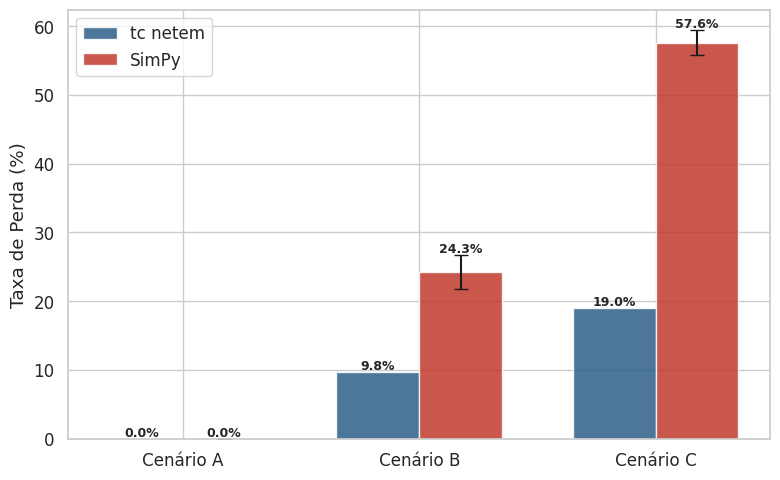

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, tc_vals, width, label='tc netem',
       color='#2C5F8A', alpha=0.85)
ax.bar(x + width/2, sim_means, width, yerr=sim_ci95s,
       capsize=5, label='SimPy',
       color='#C0392B', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Cenário {sc}' for sc in cenarios])
ax.set_ylabel('Taxa de Perda (%)')
ax.legend()

for i, (tc, sm, ci) in enumerate(zip(tc_vals, sim_means, sim_ci95s)):
    ax.text(i - width/2, tc + 0.3, f'{tc:.1f}%',
            ha='center', fontsize=9, fontweight='bold')
    ax.text(i + width/2, sm + ci + 0.3, f'{sm:.1f}%',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('tarefa2_perda_configurada_vs_simulada.png', dpi=150, bbox_inches='tight')
plt.show()

#Tarefa 3 - Simulação de Timeout

In [ ]:
print("Executando Tarefa 3 — Simulação de Timeout...")

# Retransmissões reais da Fase 1
retrans_real = {
    'A': df_rudp[df_rudp.scenario == 'A']['retransmissions'].values,
    'B': df_rudp[df_rudp.scenario == 'B']['retransmissions'].values,
    'C': df_rudp[df_rudp.scenario == 'C']['retransmissions'].values,
}

# Retransmissões simuladas
retrans_sim = {}
for sc in ['A', 'B', 'C']:
    results = run_scenario(sc, FILE_1MB, n_runs=N_RUNS)
    retrans_sim[sc] = np.array([r.retransmissions for r in results])

cenarios  = ['A', 'B', 'C']
labels_sc = ['Cenário A\n(0% / 10ms)',
             'Cenário B\n(10% / 50ms)',
             'Cenário C\n(20% / 100ms)']

r_means = [retrans_real[sc].mean() for sc in cenarios]
r_cis   = [ci95(retrans_real[sc])  for sc in cenarios]
s_means = [retrans_sim[sc].mean()  for sc in cenarios]
s_cis   = [ci95(retrans_sim[sc])   for sc in cenarios]

x     = np.arange(len(cenarios))
width = 0.35

# Tabela
print("\n=== Tarefa 3 — Retransmissões Real vs Simulado ===")
print(f"{'Cenário':<10} {'Real média':>12} {'Real IC95':>12} "
      f"{'Sim média':>12} {'Sim IC95':>12} {'Erro %':>10}")
print("-" * 70)
for sc in cenarios:
    rm  = retrans_real[sc].mean()
    rci = ci95(retrans_real[sc])
    sm  = retrans_sim[sc].mean()
    sci = ci95(retrans_sim[sc])
    err = abs(rm - sm) / rm * 100 if rm > 0 else 0.0
    print(f"{sc:<10} {rm:>12.1f} {rci:>12.1f} "
          f"{sm:>12.1f} {sci:>12.1f} {err:>10.1f}%")

print("\n✓ Tarefa 3 concluída")

Executando Tarefa 3 — Simulação de Timeout...

=== Tarefa 3 — Retransmissões Real vs Simulado ===
Cenário      Real média    Real IC95    Sim média     Sim IC95     Erro %
----------------------------------------------------------------------
A                   0.0          0.0          0.0          0.0        0.0%
B                 942.5         66.3         84.6         11.5       91.0%
C                1955.2        174.8        355.1         24.7       81.8%

✓ Tarefa 3 concluída


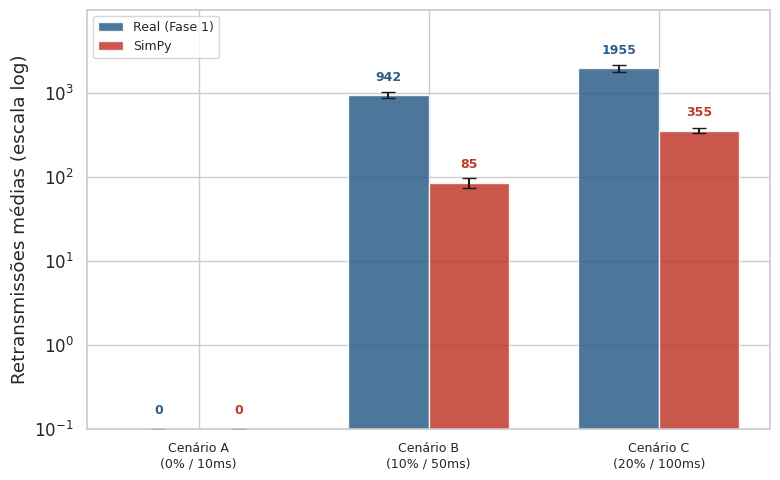

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, [max(v, 0.1) for v in r_means],
               width, yerr=r_cis, capsize=5,
               label='Real (Fase 1)',
               color='#2C5F8A', alpha=0.85)
bars2 = ax.bar(x + width/2, [max(v, 0.1) for v in s_means],
               width, yerr=s_cis, capsize=5,
               label='SimPy',
               color='#C0392B', alpha=0.85)

ax.set_yscale('log')
ax.set_ylim(0.1, max(max(r_means), max(s_means)) * 5)
ax.set_xticks(x)
ax.set_xticklabels(labels_sc, fontsize=9)
ax.set_ylabel('Retransmissões médias (escala log)')
ax.legend(fontsize=9, loc='upper left')

for bar, val in zip(bars1, r_means):
    label = '0' if val == 0 else f'{val:.0f}'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.5,
            label, ha='center', fontsize=9,
            fontweight='bold', color='#2C5F8A')
for bar, val in zip(bars2, s_means):
    label = '0' if val == 0 else f'{val:.0f}'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.5,
            label, ha='center', fontsize=9,
            fontweight='bold', color='#C0392B')

plt.tight_layout()
plt.savefig('tarefa3_retrans_real_vs_sim.png', dpi=150, bbox_inches='tight')
plt.show()

#Tarefa 4 - Throughput

In [ ]:
print("Executando Tarefa 4 — Curva de Vazão...")

FILE_SIZES_MB = [1, 2, 3]
FILE_SIZES    = [f * 1024 * 1024 for f in FILE_SIZES_MB]

# Throughput real da Fase 1 (apenas 1MB — ponto de ancoragem)
tp_real = {
    'A': df_rudp[df_rudp.scenario == 'A']['throughput_kbps'].mean(),
    'B': df_rudp[df_rudp.scenario == 'B']['throughput_kbps'].mean(),
    'C': df_rudp[df_rudp.scenario == 'C']['throughput_kbps'].mean(),
}

# Simulação para cada tamanho de arquivo e cenário
curva_tp = {sc: [] for sc in ['A', 'B', 'C']}
curva_ci = {sc: [] for sc in ['A', 'B', 'C']}

for sc in ['A', 'B', 'C']:
    for fsize in FILE_SIZES:
        results = run_scenario(sc, fsize, n_runs=N_RUNS)
        tps     = [r.throughput_kbps for r in results]
        curva_tp[sc].append(np.mean(tps))
        curva_ci[sc].append(ci95(tps))
    print(f"  Cenário {sc} concluído")

# Gráfico
cores = {'A': '#A8C8E8', 'B': '#F4B98A', 'C': '#B5D5A8'}
cores_real = {'A': '#2C5F8A', 'B': '#8B4513', 'C': '#2E7D32'}

# Tabela resumo
print("\n=== Tarefa 4 — Throughput Simulado por Tamanho de Arquivo ===")
print(f"{'Cenário':<10} {'1MB (KB/s)':>12} {'2MB (KB/s)':>12} "
      f"{'3MB (KB/s)':>12} {'Real 1MB':>12}")
print("-" * 60)
for sc in ['A', 'B', 'C']:
    vals = curva_tp[sc]
    print(f"{sc:<10} {vals[0]:>12.1f} {vals[1]:>12.1f} "
          f"{vals[2]:>12.1f} {tp_real[sc]:>12.1f}")

print("\n✓ Tarefa 4 concluída")

Executando Tarefa 4 — Curva de Vazão...
  Cenário A concluído
  Cenário B concluído
  Cenário C concluído

=== Tarefa 4 — Throughput Simulado por Tamanho de Arquivo ===
Cenário      1MB (KB/s)   2MB (KB/s)   3MB (KB/s)     Real 1MB
------------------------------------------------------------
A                5743.1       5860.9       5902.7       5112.6
B                 394.7        419.7        405.1        411.2
C                 103.9        106.6        106.0        108.4

✓ Tarefa 4 concluída


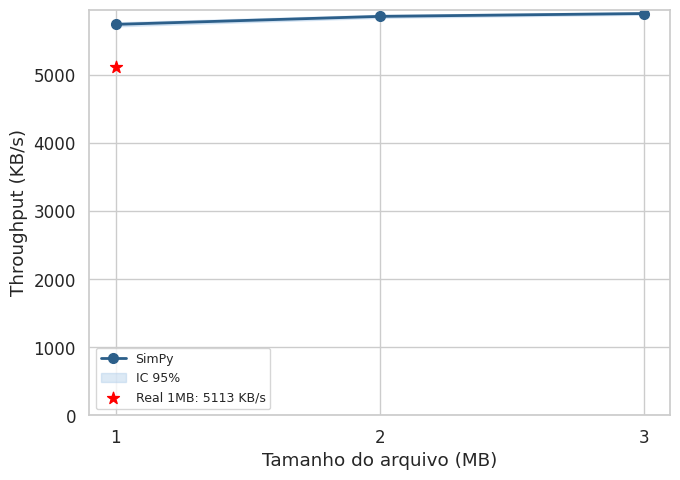

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = 'A'
ax.plot(FILE_SIZES_MB, curva_tp[sc], 'o-',
        color=cores_real[sc], linewidth=2,
        markersize=7, label='SimPy')
ax.fill_between(FILE_SIZES_MB,
                [t - c for t, c in zip(curva_tp[sc], curva_ci[sc])],
                [t + c for t, c in zip(curva_tp[sc], curva_ci[sc])],
                color=cores[sc], alpha=0.4, label='IC 95%')
ax.scatter([1], [tp_real[sc]], color='red', zorder=5,
           s=80, marker='*', label=f'Real 1MB: {tp_real[sc]:.0f} KB/s')
ax.set_xlabel('Tamanho do arquivo (MB)')
ax.set_ylabel('Throughput (KB/s)')
ax.set_xticks(FILE_SIZES_MB)
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('tarefa4_vazao_cenario_A.png', dpi=150, bbox_inches='tight')
plt.show()

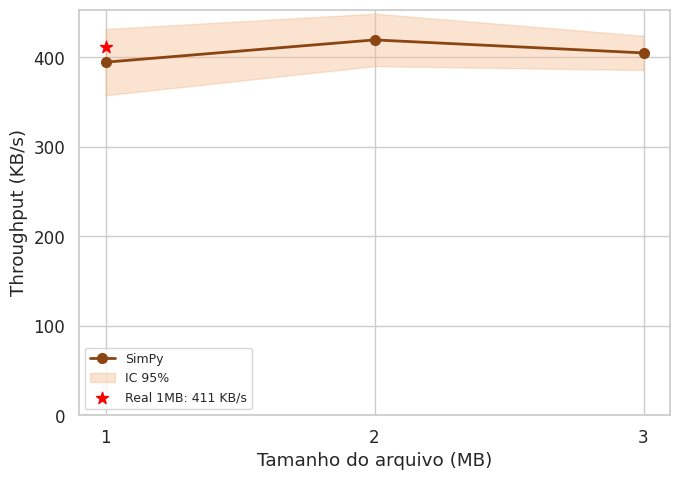

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = 'B'
ax.plot(FILE_SIZES_MB, curva_tp[sc], 'o-',
        color=cores_real[sc], linewidth=2,
        markersize=7, label='SimPy')
ax.fill_between(FILE_SIZES_MB,
                [t - c for t, c in zip(curva_tp[sc], curva_ci[sc])],
                [t + c for t, c in zip(curva_tp[sc], curva_ci[sc])],
                color=cores[sc], alpha=0.4, label='IC 95%')
ax.scatter([1], [tp_real[sc]], color='red', zorder=5,
           s=80, marker='*', label=f'Real 1MB: {tp_real[sc]:.0f} KB/s')
ax.set_xlabel('Tamanho do arquivo (MB)')
ax.set_ylabel('Throughput (KB/s)')
ax.set_xticks(FILE_SIZES_MB)
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('tarefa4_vazao_cenario_B.png', dpi=150, bbox_inches='tight')
plt.show()

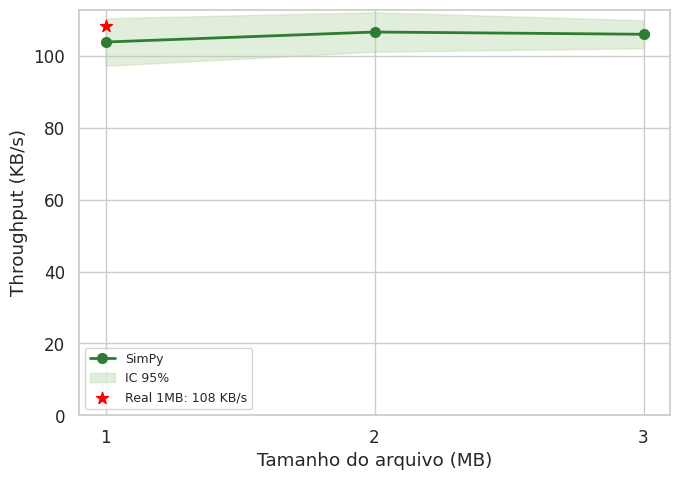

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = 'C'
ax.plot(FILE_SIZES_MB, curva_tp[sc], 'o-',
        color=cores_real[sc], linewidth=2,
        markersize=7, label='SimPy')
ax.fill_between(FILE_SIZES_MB,
                [t - c for t, c in zip(curva_tp[sc], curva_ci[sc])],
                [t + c for t, c in zip(curva_tp[sc], curva_ci[sc])],
                color=cores[sc], alpha=0.4, label='IC 95%')
ax.scatter([1], [tp_real[sc]], color='red', zorder=5,
           s=80, marker='*', label=f'Real 1MB: {tp_real[sc]:.0f} KB/s')
ax.set_xlabel('Tamanho do arquivo (MB)')
ax.set_ylabel('Throughput (KB/s)')
ax.set_xticks(FILE_SIZES_MB)
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('tarefa4_vazao_cenario_C.png', dpi=150, bbox_inches='tight')
plt.show()

#Tarefa 5 - Sensibilidade da Janela

In [ ]:
print("Executando Tarefa 5 — Sensibilidade da Janela...")

JANELAS = [1, 2, 4, 8, 16, 32, 64]

# Simulação para cada janela e cenário
curva_janela_tp  = {sc: [] for sc in ['A', 'B', 'C']}
curva_janela_ci  = {sc: [] for sc in ['A', 'B', 'C']}
curva_janela_rt  = {sc: [] for sc in ['A', 'B', 'C']}

for sc in ['A', 'B', 'C']:
    for w in JANELAS:
        results = run_scenario(sc, FILE_1MB, n_runs=N_RUNS, window_size=w)
        tps     = [r.throughput_kbps  for r in results]
        rts     = [r.retransmissions  for r in results]
        curva_janela_tp[sc].append(np.mean(tps))
        curva_janela_ci[sc].append(ci95(tps))
        curva_janela_rt[sc].append(np.mean(rts))
    print(f"  Cenário {sc} concluído")

# Marca janela atual (W=16)
JANELA_ATUAL = 16
idx_atual    = JANELAS.index(JANELA_ATUAL)

# Gráfico — 2 linhas: throughput e retransmissões
cores      = {'A': '#2C5F8A', 'B': '#8B4513', 'C': '#2E7D32'}
cores_fill = {'A': '#A8C8E8', 'B': '#F4B98A', 'C': '#B5D5A8'}

# Tabela resumo
print("\n=== Tarefa 5 — Throughput por Tamanho de Janela (KB/s) ===")
header = f"{'Janela W':<10}" + "".join(f"{'Cen '+sc:>12}" for sc in ['A','B','C'])
print(header)
print("-" * 46)
for j, w in enumerate(JANELAS):
    linha = f"{w:<10}"
    for sc in ['A', 'B', 'C']:
        linha += f"{curva_janela_tp[sc][j]:>12.1f}"
    if w == JANELA_ATUAL:
        linha += "  ← W atual"
    print(linha)

print("\n✓ Tarefa 5 concluída")

Executando Tarefa 5 — Sensibilidade da Janela...
  Cenário A concluído
  Cenário B concluído
  Cenário C concluído

=== Tarefa 5 — Throughput por Tamanho de Janela (KB/s) ===
Janela W         Cen A       Cen B       Cen C
----------------------------------------------
1                399.7        70.8        31.4
2                790.7       124.6        50.3
4               1550.2       200.9        71.6
8               3003.3       299.1        92.3
16              5743.1       394.7       103.9  ← W atual
32             10918.5       486.0       124.7
64             20975.3       544.6       118.6

✓ Tarefa 5 concluída


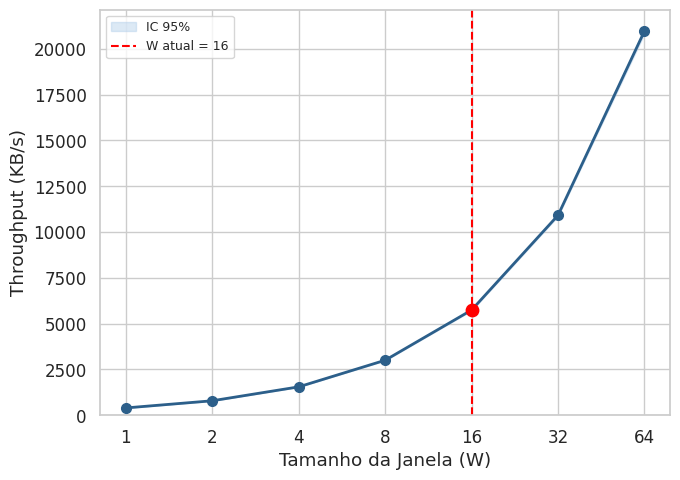

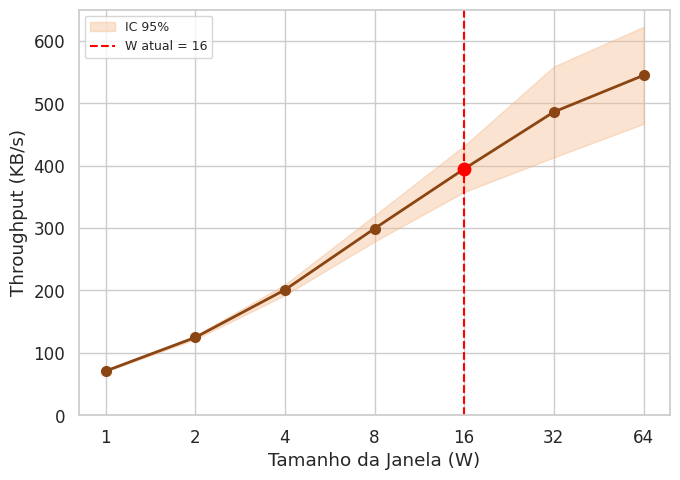

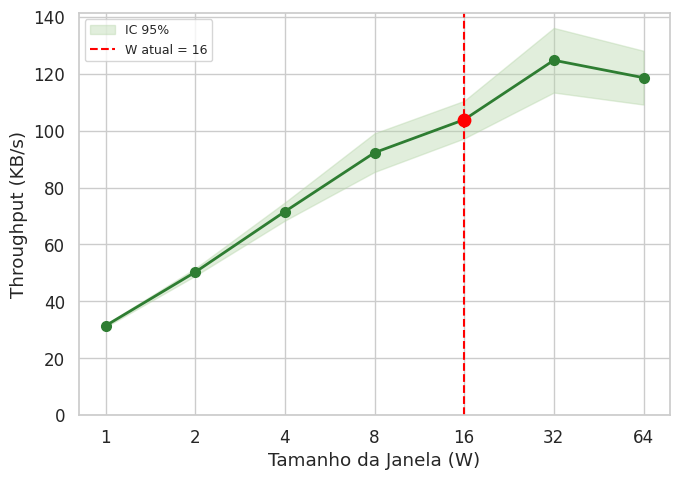

In [ ]:
for sc in ['A', 'B', 'C']:
    tps = curva_janela_tp[sc]
    cis = curva_janela_ci[sc]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(JANELAS, tps, 'o-', color=cores[sc], linewidth=2, markersize=7)
    ax.fill_between(JANELAS,
                    [t - c for t, c in zip(tps, cis)],
                    [t + c for t, c in zip(tps, cis)],
                    color=cores_fill[sc], alpha=0.4, label='IC 95%')
    ax.axvline(JANELA_ATUAL, color='red', linestyle='--',
               linewidth=1.5, label=f'W atual = {JANELA_ATUAL}')
    ax.scatter([JANELA_ATUAL], [tps[idx_atual]],
               color='red', zorder=5, s=80)
    ax.set_xlabel('Tamanho da Janela (W)')
    ax.set_ylabel('Throughput (KB/s)')
    ax.set_xscale('log', base=2)
    ax.set_xticks(JANELAS)
    ax.set_xticklabels(JANELAS)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(f'tarefa5_throughput_cenario_{sc}.png', dpi=150, bbox_inches='tight')
    plt.show()

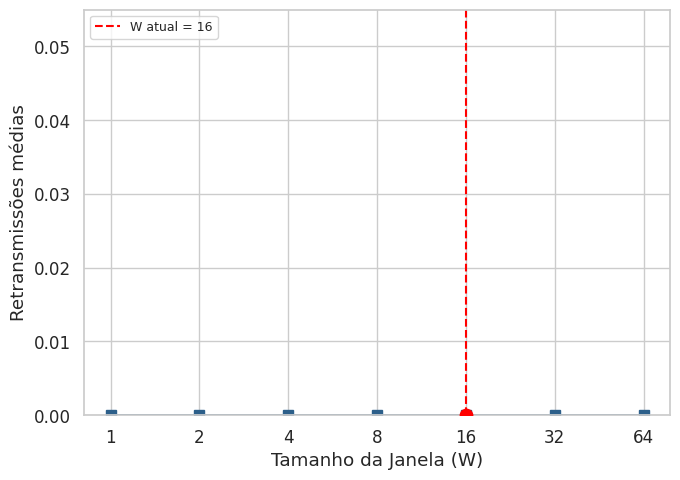

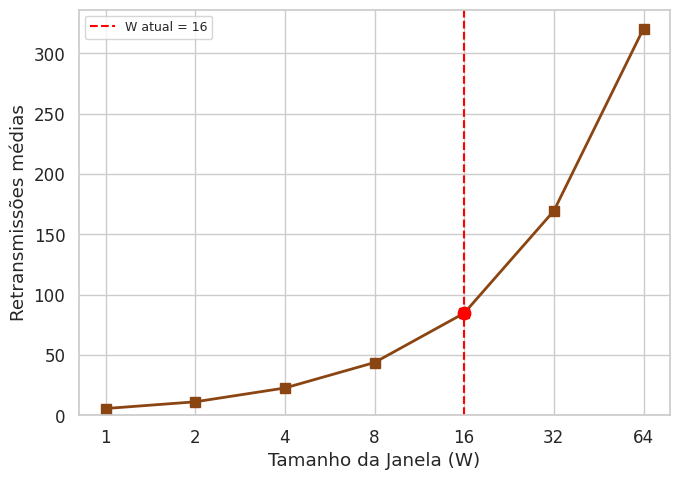

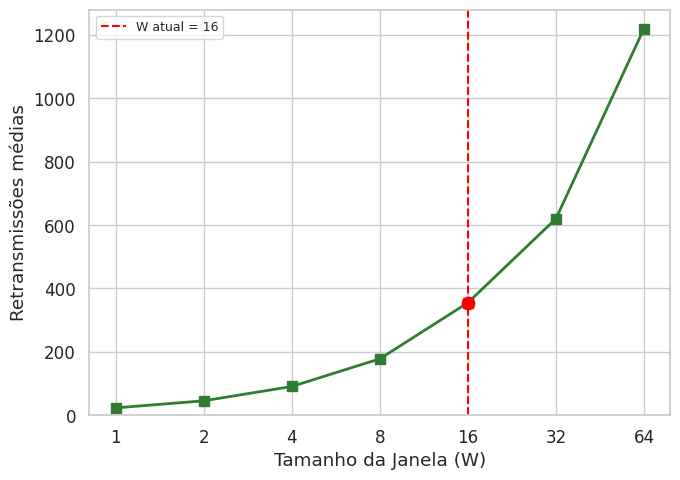

In [ ]:
for sc in ['A', 'B', 'C']:
    rts = curva_janela_rt[sc]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(JANELAS, rts, 's-', color=cores[sc], linewidth=2, markersize=7)
    ax.axvline(JANELA_ATUAL, color='red', linestyle='--',
               linewidth=1.5, label=f'W atual = {JANELA_ATUAL}')
    ax.scatter([JANELA_ATUAL], [rts[idx_atual]],
               color='red', zorder=5, s=80)
    ax.set_xlabel('Tamanho da Janela (W)')
    ax.set_ylabel('Retransmissões médias')
    ax.set_xscale('log', base=2)
    ax.set_xticks(JANELAS)
    ax.set_xticklabels(JANELAS)
    ax.legend(fontsize=9, loc='upper left')
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(f'tarefa5_retrans_cenario_{sc}.png', dpi=150, bbox_inches='tight')
    plt.show()

#Tarefa 6 - Validação de RTT

In [ ]:
print("Executando Tarefa 6 — Validação de RTT...")

# RTT esperado pelo tc
rtt_tc = {
    'A': SCENARIOS['A']['delay_mean'] * 2 * 1000,
    'B': SCENARIOS['B']['delay_mean'] * 2 * 1000,
    'C': SCENARIOS['C']['delay_mean'] * 2 * 1000,
}

# RTT simulado — coleta média e IC 95% por cenário
rtt_sim_mean = {}
rtt_sim_ci   = {}
rtt_sim_std  = {}

for sc in ['A', 'B', 'C']:
    results = run_scenario(sc, FILE_1MB, n_runs=N_RUNS)
    rtts    = [r.rtt_mean * 1000 for r in results]
    rtt_sim_mean[sc] = np.mean(rtts)
    rtt_sim_ci[sc]   = ci95(rtts)
    rtt_sim_std[sc]  = np.std(rtts)

cenarios  = ['A', 'B', 'C']
labels_sc = ['Cenário A\n(0% / 10ms)',
             'Cenário B\n(10% / 50ms)',
             'Cenário C\n(20% / 100ms)']

tc_vals  = [rtt_tc[sc]       for sc in cenarios]
sim_vals = [rtt_sim_mean[sc] for sc in cenarios]
sim_cis  = [rtt_sim_ci[sc]   for sc in cenarios]

x     = np.arange(len(cenarios))
width = 0.35

# Tabela
print("\n=== Tarefa 6 — RTT (ms): tc vs Simulado ===")
print(f"{'Cenário':<10} {'tc netem':>12} {'Simulado':>12} "
      f"{'IC 95%':>10} {'Erro abs (ms)':>15}")
print("-" * 62)
for sc in cenarios:
    tc  = rtt_tc[sc]
    sim = rtt_sim_mean[sc]
    ci_v = rtt_sim_ci[sc]
    err  = abs(tc - sim)
    print(f"{sc:<10} {tc:>12.1f} {sim:>12.1f} "
          f"{ci_v:>10.3f} {err:>15.3f}")
print("\n✓ Tarefa 6 concluída")

Executando Tarefa 6 — Validação de RTT...

=== Tarefa 6 — RTT (ms): tc vs Simulado ===
Cenário        tc netem     Simulado     IC 95%   Erro abs (ms)
--------------------------------------------------------------
A                  10.0         10.0      0.027           0.005
B                  50.0         50.1      0.148           0.100
C                 100.0        100.0      0.182           0.006

✓ Tarefa 6 concluída


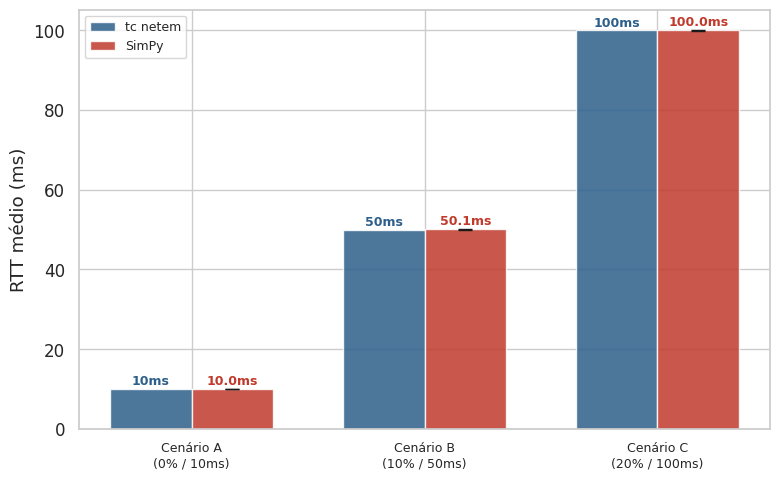

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, tc_vals, width,
               label='tc netem',
               color='#2C5F8A', alpha=0.85)
bars2 = ax.bar(x + width/2, sim_vals, width,
               yerr=sim_cis, capsize=5,
               label='SimPy',
               color='#C0392B', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels_sc, fontsize=9)
ax.set_ylabel('RTT médio (ms)')
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(bottom=0)

for bar, val in zip(bars1, tc_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 1, f'{val:.0f}ms',
            ha='center', fontsize=9,
            fontweight='bold', color='#2C5F8A')
for bar, val, ci_v in zip(bars2, sim_vals, sim_cis):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + ci_v + 1, f'{val:.1f}ms',
            ha='center', fontsize=9,
            fontweight='bold', color='#C0392B')

plt.tight_layout()
plt.savefig('tarefa6_rtt_tc_vs_simulado.png', dpi=150, bbox_inches='tight')
plt.show()

#Tarefa 7 - Impacto do Jitter

In [ ]:
print("Executando Tarefa 7 — Impacto do Jitter...")

JITTER_FATORES = [0.5, 1.0, 2.0, 4.0]
JITTER_LABELS  = ['0.5×\n(baixo)', '1.0×\n(base)', '2.0×\n(alto)', '4.0×\n(extremo)']

# Simula cada fator de jitter para cada cenário
curva_tp  = {sc: [] for sc in ['A', 'B', 'C']}
curva_ci  = {sc: [] for sc in ['A', 'B', 'C']}
curva_std = {sc: [] for sc in ['A', 'B', 'C']}

for sc in ['A', 'B', 'C']:
    for jf in JITTER_FATORES:
        results = run_scenario(sc, FILE_1MB, n_runs=N_RUNS,
                               jitter_factor=jf)
        tps = [r.throughput_kbps for r in results]
        curva_tp[sc].append(np.mean(tps))
        curva_ci[sc].append(ci95(tps))
        curva_std[sc].append(np.std(tps))
    print(f"  Cenário {sc} concluído")

# Normaliza throughput em relação ao jitter base (1.0×)
# para mostrar degradação percentual
degradacao = {sc: [] for sc in ['A', 'B', 'C']}
idx_base   = JITTER_FATORES.index(1.0)
for sc in ['A', 'B', 'C']:
    base_tp = curva_tp[sc][idx_base]
    for tp in curva_tp[sc]:
        degradacao[sc].append((base_tp - tp) / base_tp * 100)

x     = np.arange(len(JITTER_FATORES))
width = 0.25
cores = {'A': '#2C5F8A', 'B': '#C0392B', 'C': '#2E7D32'}
cores_fill = {'A': '#A8C8E8', 'B': '#F4B98A', 'C': '#B5D5A8'}

# Tabela
print("\n=== Tarefa 7 — Throughput e Degradação por Fator de Jitter ===")
print(f"{'Jitter':<14}" +
      "".join(f"{'Cen '+sc+' (KB/s)':>16}" for sc in ['A','B','C']))
print("-" * 62)
for j, (jf, jl) in enumerate(zip(JITTER_FATORES, JITTER_LABELS)):
    linha = f"{jl.replace(chr(10),' '):<14}"
    for sc in ['A', 'B', 'C']:
        tp  = curva_tp[sc][j]
        deg = degradacao[sc][j]
        linha += f"{tp:>10.0f} ({deg:>+5.1f}%)"
    print(linha)

print("\n✓ Tarefa 7 concluída")

Executando Tarefa 7 — Impacto do Jitter...
  Cenário A concluído
  Cenário B concluído
  Cenário C concluído

=== Tarefa 7 — Throughput e Degradação por Fator de Jitter ===
Jitter            Cen A (KB/s)    Cen B (KB/s)    Cen C (KB/s)
--------------------------------------------------------------
0.5× (baixo)        6046 ( -5.3%)       406 ( -2.8%)       106 ( -1.9%)
1.0× (base)         5743 ( +0.0%)       395 ( +0.0%)       104 ( +0.0%)
2.0× (alto)         5209 ( +9.3%)       373 ( +5.6%)        98 ( +5.3%)
4.0× (extremo)      4313 (+24.9%)       336 (+15.0%)        94 ( +9.7%)

✓ Tarefa 7 concluída


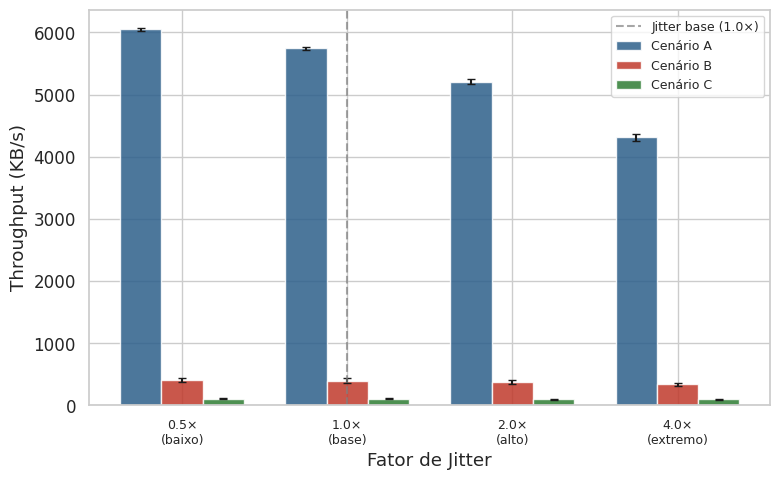

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, sc in enumerate(['A', 'B', 'C']):
    offset = (i - 1) * width
    ax.bar(x + offset,
           curva_tp[sc],
           width,
           yerr=curva_ci[sc],
           capsize=3,
           label=f'Cenário {sc}',
           color=cores[sc],
           alpha=0.85)

ax.axvline(idx_base, color='gray', linestyle='--',
           linewidth=1.5, alpha=0.7, label='Jitter base (1.0×)')
ax.set_xticks(x)
ax.set_xticklabels(JITTER_LABELS, fontsize=9)
ax.set_xlabel('Fator de Jitter')
ax.set_ylabel('Throughput (KB/s)')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('tarefa7_throughput_vs_jitter.png', dpi=150, bbox_inches='tight')
plt.show()

#Tarefa 8 - Cenário de Estresse

In [ ]:
print("Executando Tarefa 8 — Cenário de Estresse (25% perda)...")

FILE_1MB = 1 * 1024 * 1024

# Simula cenário de estresse: delay do Cenário C + 25% perda efetiva
# 25% efetiva → ~13.4% em cada lado: 1-(1-0.134)^2 ≈ 0.25
LOSS_ESTRESSE  = 0.134
DELAY_ESTRESSE = 0.050

results_estresse = []
for i in range(N_RUNS):
    sim = RUDPSimulator(
        file_size_bytes = FILE_1MB,
        delay_mean      = DELAY_ESTRESSE,
        delay_std       = 0.006,
        loss_rate       = LOSS_ESTRESSE,
        window_size     = WINDOW_SIZE,
        seed            = i * 42 + 999,
    )
    r           = sim.run()
    r.scenario  = 'Estresse'
    r.loss_rate = LOSS_ESTRESSE
    results_estresse.append(r)

s_est = summarize(results_estresse)

# Simula cada cenário com seus parâmetros corretos
resultados_comp = {}
for sc in ['A', 'B', 'C']:
    results = run_scenario(sc, FILE_1MB, n_runs=N_RUNS)
    resultados_comp[sc] = summarize(results)

# Verificação
print("\n=== Verificação ===")
for sc in ['A', 'B', 'C']:
    print(f"Cenário {sc}: "
          f"{resultados_comp[sc]['throughput_mean']:.1f} KB/s | "
          f"{resultados_comp[sc]['elapsed_mean']:.3f}s | "
          f"{resultados_comp[sc]['retrans_mean']:.0f} retrans")
print(f"Estresse:   "
      f"{s_est['throughput_mean']:.1f} KB/s | "
      f"{s_est['elapsed_mean']:.3f}s | "
      f"{s_est['retrans_mean']:.0f} retrans")

# Dados para gráfico
labels_todos = [
    'Cenário A\n(0% / 10ms)',
    'Cenário B\n(10% / 50ms)',
    'Cenário C\n(20% / 100ms)',
    'Estresse\n(25% / 100ms)',
]
tp_means = [resultados_comp[sc]['throughput_mean'] for sc in ['A','B','C']] + [s_est['throughput_mean']]
tp_cis   = [resultados_comp[sc]['throughput_ci95'] for sc in ['A','B','C']] + [s_est['throughput_ci95']]
el_means = [resultados_comp[sc]['elapsed_mean']    for sc in ['A','B','C']] + [s_est['elapsed_mean']]
el_cis   = [resultados_comp[sc]['elapsed_ci95']    for sc in ['A','B','C']] + [s_est['elapsed_ci95']]
rt_means = [resultados_comp[sc]['retrans_mean']    for sc in ['A','B','C']] + [s_est['retrans_mean']]
rt_cis   = [resultados_comp[sc]['retrans_ci95']    for sc in ['A','B','C']] + [s_est['retrans_ci95']]

cores_bar = ['#A8C8E8', '#F4B98A', '#B5D5A8', '#C0392B']
x = np.arange(len(labels_todos))

print("\n✓ Tarefa 8 concluída")

Executando Tarefa 8 — Cenário de Estresse (25% perda)...

=== Verificação ===
Cenário A: 5743.1 KB/s | 0.178s | 0 retrans
Cenário B: 394.7 KB/s | 2.737s | 85 retrans
Cenário C: 103.9 KB/s | 10.114s | 355 retrans
Estresse:   62.1 KB/s | 17.041s | 648 retrans

✓ Tarefa 8 concluída


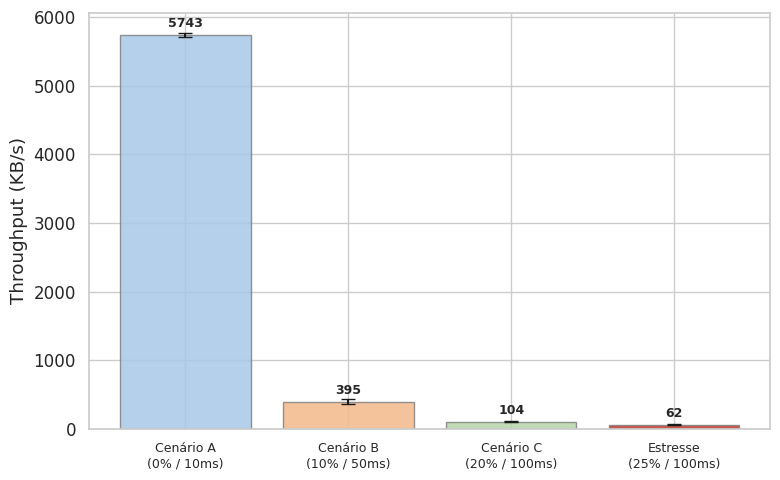

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(x, tp_means, yerr=tp_cis, capsize=5,
              color=cores_bar, alpha=0.85, edgecolor='gray')
ax.set_xticks(x)
ax.set_xticklabels(labels_todos, fontsize=9)
ax.set_ylabel('Throughput (KB/s)')
ax.set_ylim(bottom=0)
for bar, val in zip(bars, tp_means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(tp_means)*0.02,
            f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('tarefa8_throughput_estresse.png', dpi=150, bbox_inches='tight')
plt.show()

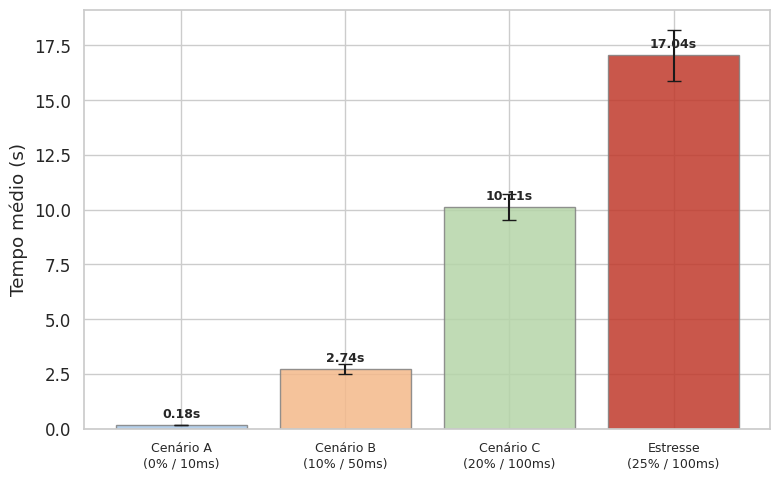

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars2 = ax.bar(x, el_means, yerr=el_cis, capsize=5,
               color=cores_bar, alpha=0.85, edgecolor='gray')
ax.set_xticks(x)
ax.set_xticklabels(labels_todos, fontsize=9)
ax.set_ylabel('Tempo médio (s)')
ax.set_ylim(bottom=0)
for bar, val in zip(bars2, el_means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(el_means)*0.02,
            f'{val:.2f}s', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('tarefa8_tempo_estresse.png', dpi=150, bbox_inches='tight')
plt.show()

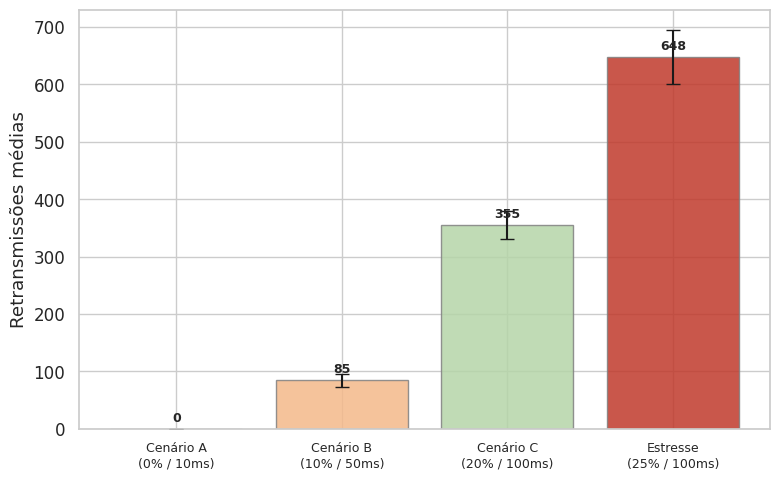

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars3 = ax.bar(x, rt_means, yerr=rt_cis, capsize=5,
               color=cores_bar, alpha=0.85, edgecolor='gray')
ax.set_xticks(x)
ax.set_xticklabels(labels_todos, fontsize=9)
ax.set_ylabel('Retransmissões médias')
ax.set_ylim(bottom=0)
for bar, val in zip(bars3, rt_means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(rt_means)*0.02,
            f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('tarefa8_retrans_estresse.png', dpi=150, bbox_inches='tight')
plt.show()

#Tarefa 9 - Análise de Eficiência

In [ ]:
print("Executando Tarefa 9 — Análise de Eficiência...")

# Eficiência teórica GBN sem perda:
# E = W / (W + 1) onde W = tamanho da janela
# Com perda p: E = (1-p) / (1 + p*(W-1))
def eficiencia_teorica_gbn(W, p):
    if p == 0:
        return W / (W + 1)
    return (1 - p) / (1 + p * (W - 1))

# Eficiência teórica por cenário com W=16
ef_teorica = {
    'A': eficiencia_teorica_gbn(WINDOW_SIZE, SCENARIOS['A']['loss_rate']),
    'B': eficiencia_teorica_gbn(WINDOW_SIZE, SCENARIOS['B']['loss_rate']),
    'C': eficiencia_teorica_gbn(WINDOW_SIZE, SCENARIOS['C']['loss_rate']),
}

# Eficiência simulada por cenário
ef_sim      = {}
ef_sim_ci   = {}
ef_sim_dist = {}

for sc in ['A', 'B', 'C']:
    results = run_scenario(sc, FILE_1MB, n_runs=N_RUNS)
    effs    = [r.efficiency for r in results]
    ef_sim[sc]      = np.mean(effs)
    ef_sim_ci[sc]   = ci95(effs)
    ef_sim_dist[sc] = np.array(effs)
    print(f"  Cenário {sc}: eficiência simulada = {np.mean(effs):.3f} "
          f"| teórica = {ef_teorica[sc]:.3f}")

# Eficiência por tamanho de janela (para contextualizar)
janelas_ef  = [1, 2, 4, 8, 16, 32, 64]
ef_janela   = {sc: [] for sc in ['A', 'B', 'C']}
for sc in ['A', 'B', 'C']:
    p = SCENARIOS[sc]['loss_rate']
    for w in janelas_ef:
        ef_janela[sc].append(eficiencia_teorica_gbn(w, p))

# Gráfico — 3 subplots
cores      = {'A': '#2C5F8A', 'B': '#C0392B', 'C': '#2E7D32'}
cores_fill = {'A': '#A8C8E8', 'B': '#F4B98A', 'C': '#B5D5A8'}
cenarios   = ['A', 'B', 'C']

# Subplot 1 — Barras: eficiência simulada vs teórica
x     = np.arange(len(cenarios))
width = 0.35

# Tabela resumo
print("\n=== Tarefa 9 — Análise de Eficiência ===")
print(f"{'Cenário':<10} {'Teórica':>10} {'Simulada':>10} "
      f"{'IC 95%':>10} {'Diferença':>12}")
print("-" * 55)
for sc in cenarios:
    teo  = ef_teorica[sc]
    sim  = ef_sim[sc]
    ci_v = ef_sim_ci[sc]
    diff = abs(teo - sim)
    print(f"{sc:<10} {teo:>10.4f} {sim:>10.4f} {ci_v:>10.4f} {diff:>12.4f}")

print("\n✓ Tarefa 9 concluída")

Executando Tarefa 9 — Análise de Eficiência...
  Cenário A: eficiência simulada = 0.500 | teórica = 0.941
  Cenário B: eficiência simulada = 0.435 | teórica = 0.754
  Cenário C: eficiência simulada = 0.315 | teórica = 0.418

=== Tarefa 9 — Análise de Eficiência ===
Cenário       Teórica   Simulada     IC 95%    Diferença
-------------------------------------------------------
A              0.9412     0.5000     0.0000       0.4412
B              0.7538     0.4353     0.0078       0.3185
C              0.4182     0.3149     0.0085       0.1033

✓ Tarefa 9 concluída


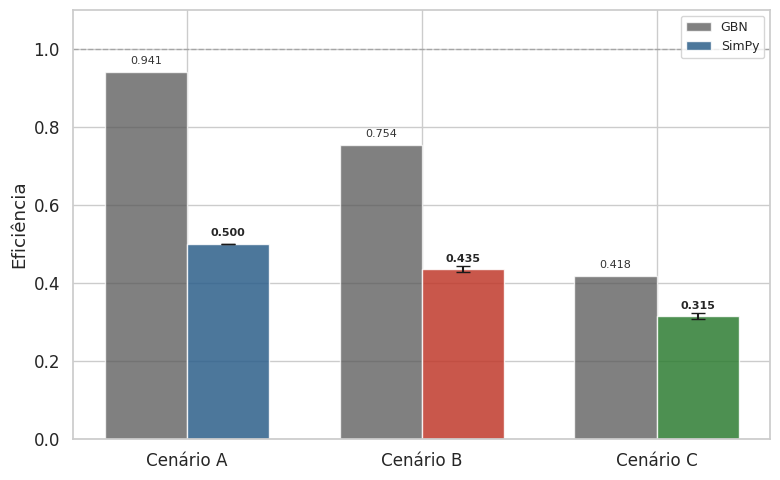

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2,
               [ef_teorica[sc] for sc in cenarios],
               width, label='GBN',
               color='#555555', alpha=0.75)
bars2 = ax.bar(x + width/2,
               [ef_sim[sc] for sc in cenarios],
               width,
               yerr=[ef_sim_ci[sc] for sc in cenarios],
               capsize=5, label='SimPy',
               color=[cores[sc] for sc in cenarios],
               alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Cenário {sc}' for sc in cenarios])
ax.set_ylabel('Eficiência')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9, loc='upper right')
ax.axhline(1.0, color='gray', linestyle='--',
           linewidth=1, alpha=0.5)

for bar, val in zip(bars1, [ef_teorica[sc] for sc in cenarios]):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.02, f'{val:.3f}',
            ha='center', fontsize=8, color='#333333')
for bar, val in zip(bars2, [ef_sim[sc] for sc in cenarios]):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.02, f'{val:.3f}',
            ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('tarefa9_eficiencia_teorica_vs_sim.png', dpi=150, bbox_inches='tight')
plt.show()

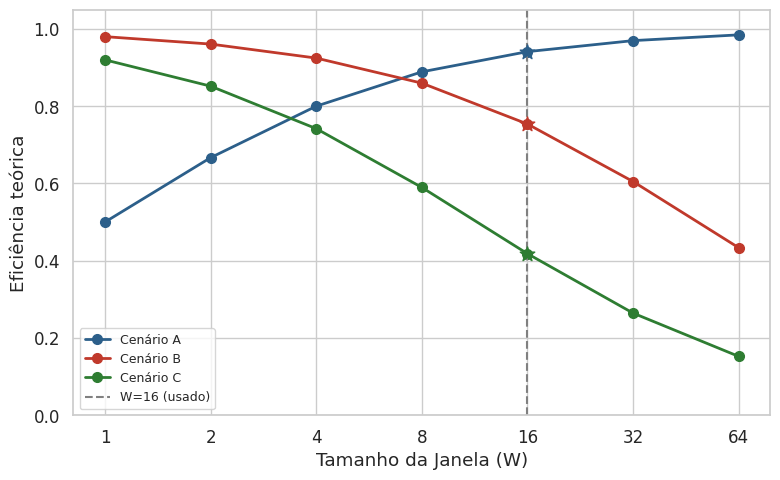

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for sc in ['A', 'B', 'C']:
    ax.plot(janelas_ef, ef_janela[sc], 'o-',
            color=cores[sc], linewidth=2,
            markersize=7, label=f'Cenário {sc}')
    idx16 = janelas_ef.index(16)
    ax.scatter([16], [ef_janela[sc][idx16]],
               color=cores[sc], s=120, zorder=5,
               marker='*')

ax.axvline(16, color='gray', linestyle='--',
           linewidth=1.5, label='W=16 (usado)')
ax.set_xscale('log', base=2)
ax.set_xticks(janelas_ef)
ax.set_xticklabels(janelas_ef)
ax.set_xlabel('Tamanho da Janela (W)')
ax.set_ylabel('Eficiência teórica')
#ax.set_title('Eficiência Teórica GBN por Janela\n'
             #'(★ = W=16 utilizado na Fase 1)')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc='lower left')

plt.tight_layout()
plt.savefig('tarefa9_eficiencia_por_janela.png', dpi=150, bbox_inches='tight')
plt.show()

#Tarefa 10 - Convergência Estatística

In [ ]:
print("Executando Tarefa 10 — Convergência Estatística...")

# Executa 30 runs para cada cenário e acumula resultados
resultados_conv = {}
for sc in ['A', 'B', 'C']:
    results = run_scenario(sc, FILE_1MB, n_runs=30)
    resultados_conv[sc] = results
    print(f"  Cenário {sc} concluído")

# Calcula média acumulada e IC 95% crescente para throughput
def convergencia(results, metrica='throughput_kbps'):
    valores = [getattr(r, metrica) for r in results]
    medias, ci_lower, ci_upper = [], [], []
    for n in range(1, len(valores) + 1):
        sub = valores[:n]
        m   = np.mean(sub)
        medias.append(m)
        if n < 2:
            ci_lower.append(m)
            ci_upper.append(m)
        else:
            ic = ci95(sub)
            ci_lower.append(m - ic)
            ci_upper.append(m + ic)
    return np.array(medias), np.array(ci_lower), np.array(ci_upper)

runs_eixo = np.arange(1, 31)

# Gráfico — 2 linhas × 3 colunas (throughput e retransmissões por cenário)
cores      = {'A': '#2C5F8A', 'B': '#C0392B', 'C': '#2E7D32'}
cores_fill = {'A': '#A8C8E8', 'B': '#F4B98A', 'C': '#B5D5A8'}

# Tabela resumo — IC 95% final com 30 execuções
print("\n=== Tarefa 10 — IC 95% Final (n=30) ===")
print(f"{'Cenário':<10} {'Throughput (KB/s)':>20} {'Retransmissões':>18} {'Tempo (s)':>16}")
print(f"{'':10} {'Média ± IC95%':>20} {'Média ± IC95%':>18} {'Média ± IC95%':>16}")
print("-" * 68)
for sc in ['A', 'B', 'C']:
    results = resultados_conv[sc]
    tps  = [r.throughput_kbps  for r in results]
    rts  = [r.retransmissions  for r in results]
    els  = [r.elapsed          for r in results]
    tp_m, tp_ci = np.mean(tps), ci95(tps)
    rt_m, rt_ci = np.mean(rts), ci95(rts)
    el_m, el_ci = np.mean(els), ci95(els)
    print(f"{sc:<10} {tp_m:>10.1f} ± {tp_ci:<7.1f} "
          f"{rt_m:>8.1f} ± {rt_ci:<7.1f} "
          f"{el_m:>6.3f} ± {el_ci:<6.3f}")

print("\n✓ Tarefa 10 concluída — todas as tarefas de validação executadas!")

Executando Tarefa 10 — Convergência Estatística...
  Cenário A concluído
  Cenário B concluído
  Cenário C concluído

=== Tarefa 10 — IC 95% Final (n=30) ===
Cenário       Throughput (KB/s)     Retransmissões        Tempo (s)
                  Média ± IC95%      Média ± IC95%    Média ± IC95%
--------------------------------------------------------------------
A              5743.1 ± 29.2         0.0 ± 0.0      0.178 ± 0.001 
B               394.7 ± 37.0        84.6 ± 11.5     2.737 ± 0.229 
C               103.9 ± 6.6        355.1 ± 24.7    10.114 ± 0.587 

✓ Tarefa 10 concluída — todas as tarefas de validação executadas!


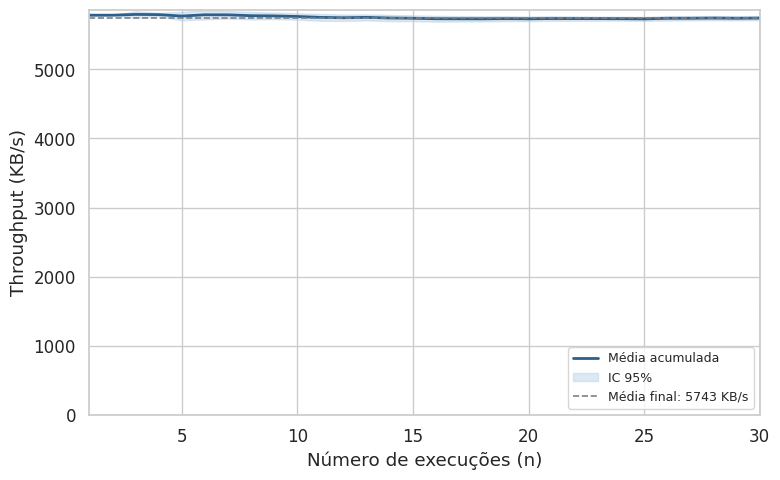

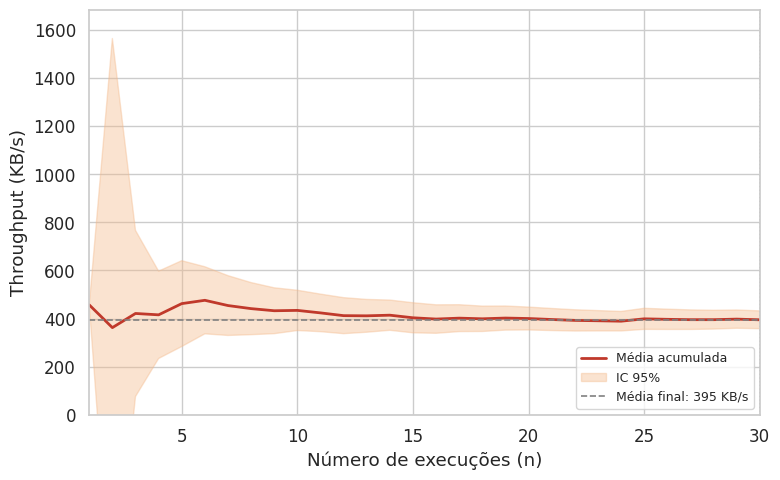

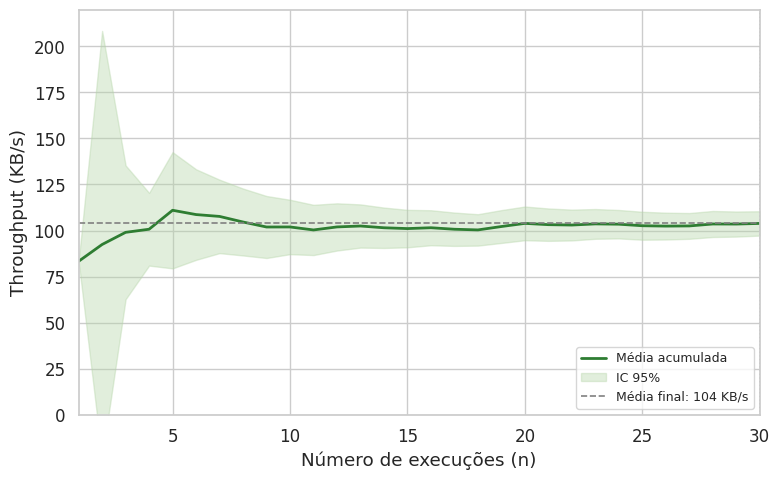

In [ ]:
for sc in ['A', 'B', 'C']:
    results = resultados_conv[sc]
    med, lo, hi = convergencia(results, 'throughput_kbps')
    valor_final = med[-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(runs_eixo, med, '-', color=cores[sc], linewidth=2,
            label='Média acumulada')
    ax.fill_between(runs_eixo, lo, hi, color=cores_fill[sc],
                    alpha=0.4, label='IC 95%')
    ax.axhline(valor_final, color='gray', linestyle='--',
               linewidth=1.2, label=f'Média final: {valor_final:.0f} KB/s')
    ax.axvline(30, color='black', linestyle=':', linewidth=1)
    ax.set_xlabel('Número de execuções (n)')
    ax.set_ylabel('Throughput (KB/s)')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim(1, 30)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(f'tarefa10_throughput_convergencia_{sc}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

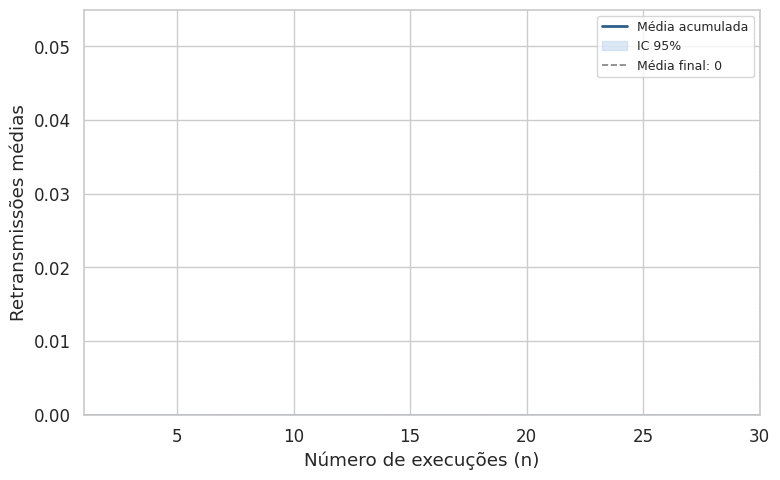

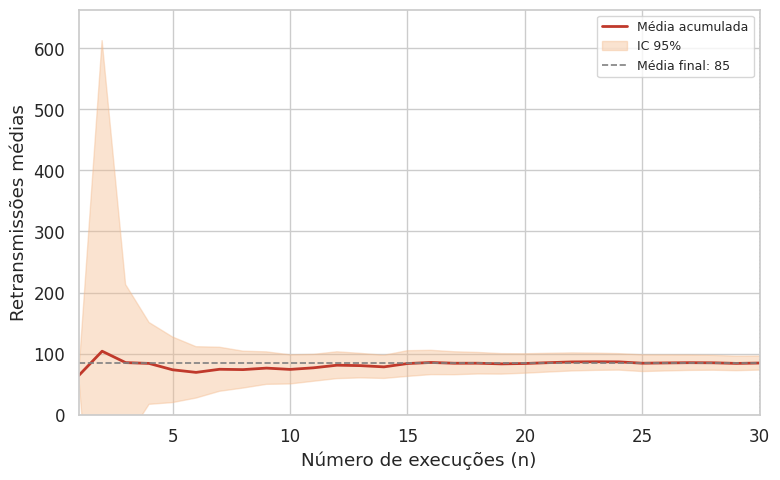

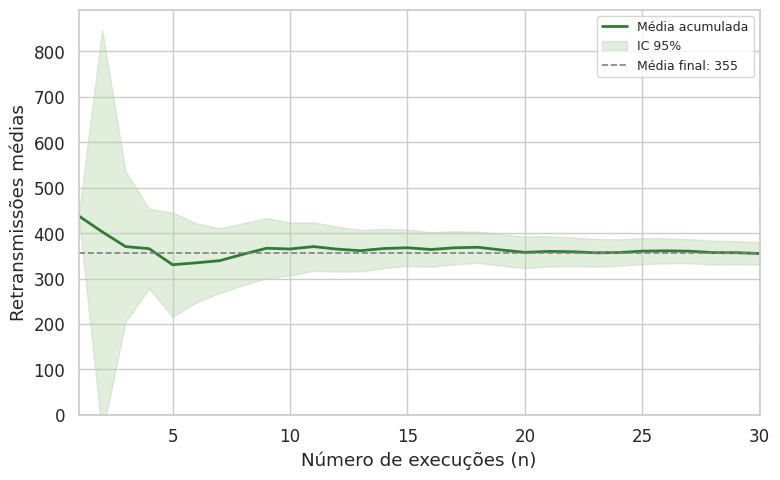

In [ ]:
for sc in ['A', 'B', 'C']:
    results = resultados_conv[sc]
    med2, lo2, hi2 = convergencia(results, 'retransmissions')
    valor_final2 = med2[-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(runs_eixo, med2, '-', color=cores[sc], linewidth=2,
            label='Média acumulada')
    ax.fill_between(runs_eixo, lo2, hi2, color=cores_fill[sc],
                    alpha=0.4, label='IC 95%')
    ax.axhline(valor_final2, color='gray', linestyle='--',
               linewidth=1.2, label=f'Média final: {valor_final2:.0f}')
    ax.axvline(30, color='black', linestyle=':', linewidth=1)
    ax.set_xlabel('Número de execuções (n)')
    ax.set_ylabel('Retransmissões médias')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim(1, 30)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(f'tarefa10_retrans_convergencia_{sc}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

Gerando comparação Real vs Simulado...


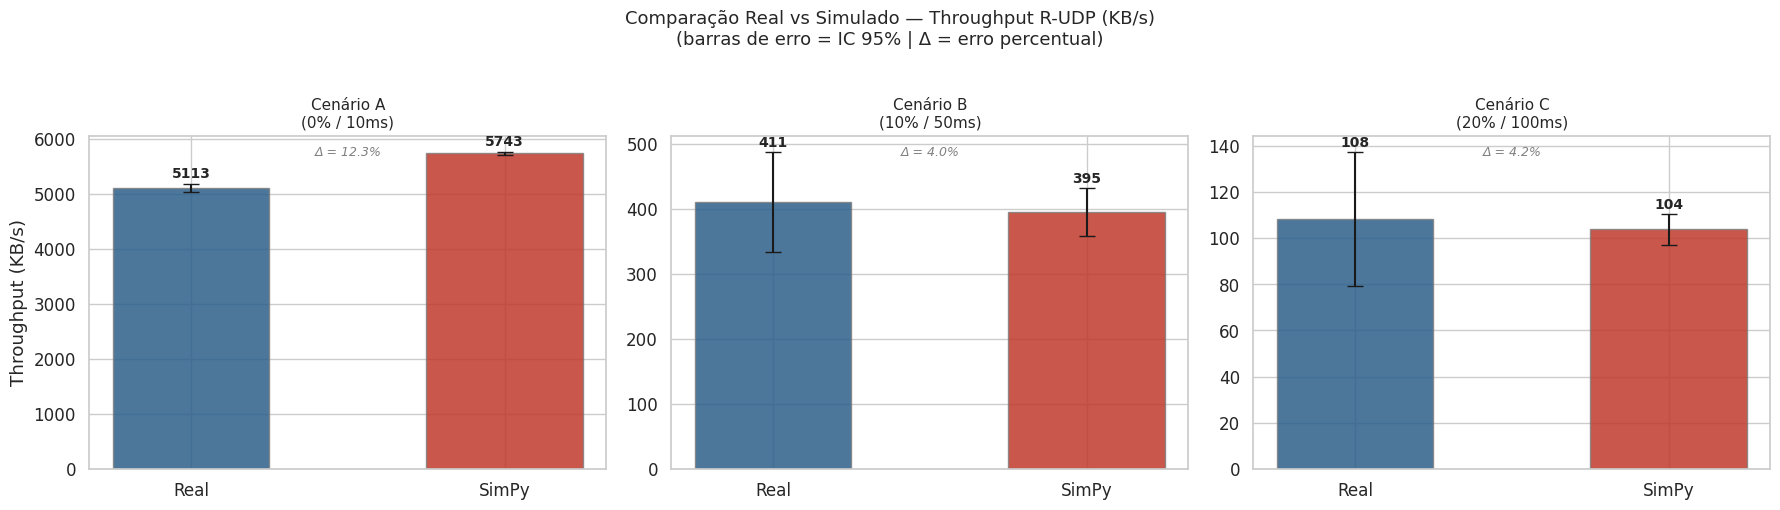

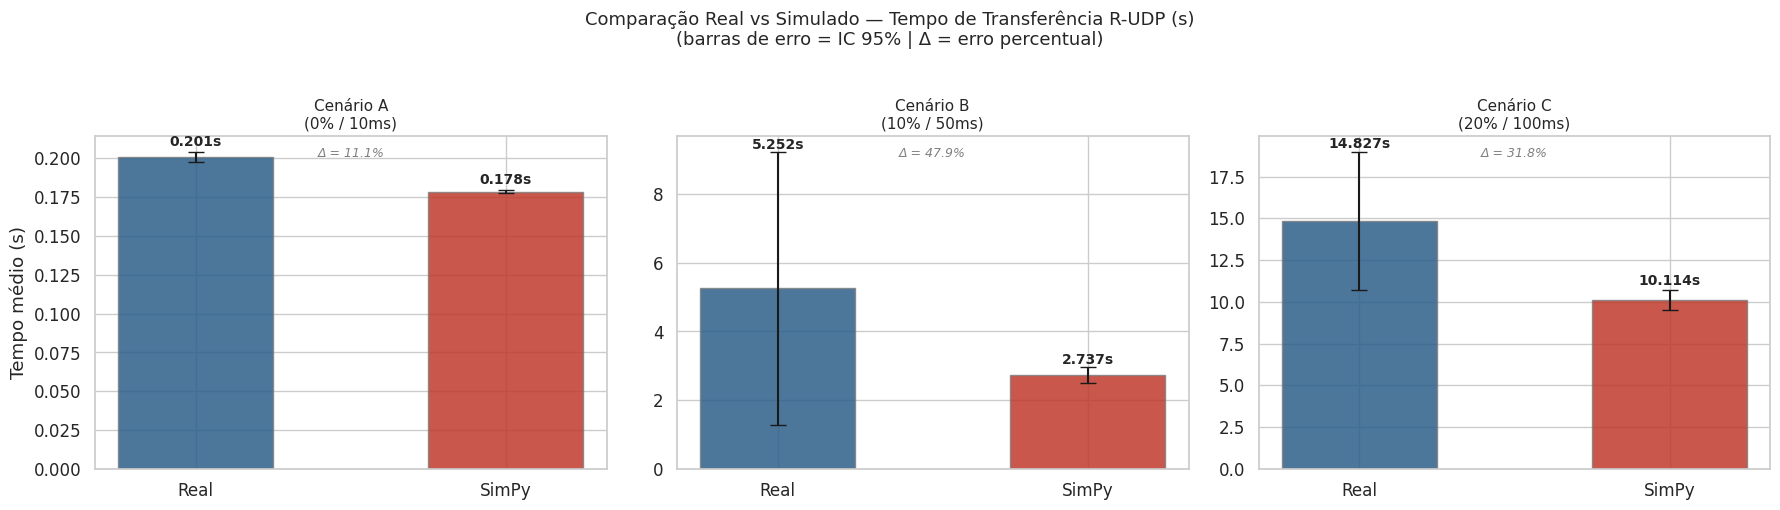

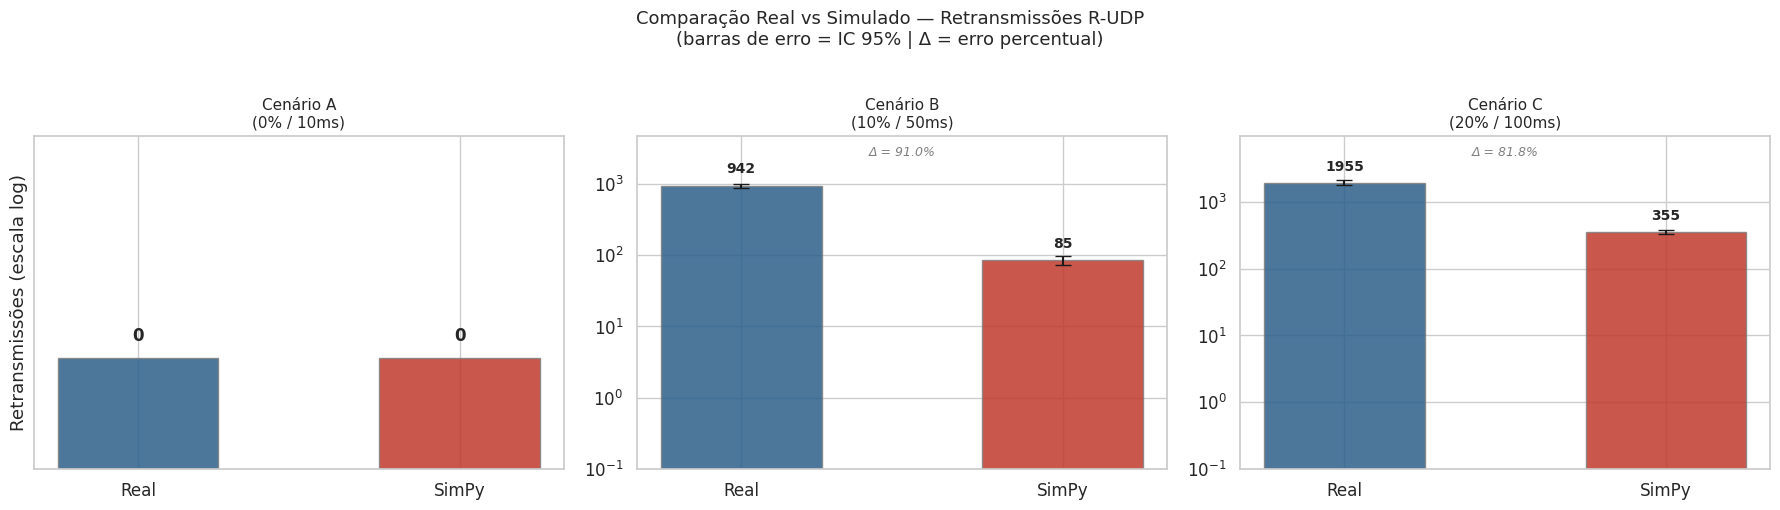


╔══════════════════════════════════════════════════════════════════════════════╗
║          COMPARAÇÃO GERAL — Real (Fase 1) vs Simulado (SimPy)               ║
╠══════════════════════════════════════════════════════════════════════════════╣
                      Throughput (KB/s)                Tempo (s)            Retrans
Cenário          Real     Simulado     Δ%      Real  Simulado     Δ%    Real Simulado   Δ%
╠══════════════════════════════════════════════════════════════════════════════╣
A              5112.6       5743.1  12.3%     0.201     0.178  11.1%     0.0     0.0  0.0%
B               411.2        394.7   4.0%     5.252     2.737  47.9%   942.5    84.6 91.0%
C               108.4        103.9   4.2%    14.827    10.114  31.8%  1955.2   355.1 81.8%
╚══════════════════════════════════════════════════════════════════════════════╝

✓ Comparação Real vs Simulado concluída!


In [ ]:
print("Gerando comparação Real vs Simulado...")

# ── Dados reais da Fase 1 ─────────────────────────────────────────────────────
real_summary = {}
for sc in ['A', 'B', 'C']:
    sub = df_rudp[df_rudp.scenario == sc]
    real_summary[sc] = {
        'throughput_mean': sub['throughput_kbps'].mean(),
        'throughput_ci95': ci95(sub['throughput_kbps'].values),
        'elapsed_mean':    sub['elapsed'].mean(),
        'elapsed_ci95':    ci95(sub['elapsed'].values),
        'retrans_mean':    sub['retransmissions'].mean(),
        'retrans_ci95':    ci95(sub['retransmissions'].values),
    }

# ── Dados simulados ───────────────────────────────────────────────────────────
sim_summary = {}
for sc in ['A', 'B', 'C']:
    results = run_scenario(sc, FILE_1MB, n_runs=30)
    sim_summary[sc] = summarize(results)

# ── Gráfico 1 — Throughput Real vs Simulado por cenário ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cores_real = '#2C5F8A'
cores_sim  = '#C0392B'
cenarios   = ['A', 'B', 'C']
labels_sc  = ['Cenário A\n(0% / 10ms)',
               'Cenário B\n(10% / 50ms)',
               'Cenário C\n(20% / 100ms)']

for i, sc in enumerate(cenarios):
    ax    = axes[i]
    r_tp  = real_summary[sc]['throughput_mean']
    r_ci  = real_summary[sc]['throughput_ci95']
    s_tp  = sim_summary[sc]['throughput_mean']
    s_ci  = sim_summary[sc]['throughput_ci95']

    bars = ax.bar(['Real', 'SimPy'],
                  [r_tp, s_tp],
                  yerr=[r_ci, s_ci],
                  capsize=6,
                  color=[cores_real, cores_sim],
                  alpha=0.85, edgecolor='gray', width=0.5)

    ax.set_title(labels_sc[i], fontsize=11)
    ax.set_ylabel('Throughput (KB/s)' if i == 0 else '')
    ax.set_ylim(bottom=0)

    for bar, val, ci_v in zip(bars, [r_tp, s_tp], [r_ci, s_ci]):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + ci_v + max(r_tp, s_tp) * 0.02,
                f'{val:.0f}', ha='center', fontsize=10,
                fontweight='bold')

    # Erro percentual
    erro = abs(r_tp - s_tp) / r_tp * 100 if r_tp > 0 else 0
    ax.text(0.5, 0.97, f'Δ = {erro:.1f}%',
            transform=ax.transAxes, ha='center',
            va='top', fontsize=9, color='gray',
            style='italic')

fig.suptitle('Comparação Real vs Simulado — Throughput R-UDP (KB/s)\n'
             '(barras de erro = IC 95% | Δ = erro percentual)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comp_throughput_real_vs_sim.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 2 — Tempo Real vs Simulado ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, sc in enumerate(cenarios):
    ax   = axes[i]
    r_el = real_summary[sc]['elapsed_mean']
    r_ci = real_summary[sc]['elapsed_ci95']
    s_el = sim_summary[sc]['elapsed_mean']
    s_ci = sim_summary[sc]['elapsed_ci95']

    bars = ax.bar(['Real', 'SimPy'],
                  [r_el, s_el],
                  yerr=[r_ci, s_ci],
                  capsize=6,
                  color=[cores_real, cores_sim],
                  alpha=0.85, edgecolor='gray', width=0.5)

    ax.set_title(labels_sc[i], fontsize=11)
    ax.set_ylabel('Tempo médio (s)' if i == 0 else '')
    ax.set_ylim(bottom=0)

    for bar, val, ci_v in zip(bars, [r_el, s_el], [r_ci, s_ci]):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + ci_v + max(r_el, s_el) * 0.02,
                f'{val:.3f}s', ha='center', fontsize=10,
                fontweight='bold')

    erro = abs(r_el - s_el) / r_el * 100 if r_el > 0 else 0
    ax.text(0.5, 0.97, f'Δ = {erro:.1f}%',
            transform=ax.transAxes, ha='center',
            va='top', fontsize=9, color='gray',
            style='italic')

fig.suptitle('Comparação Real vs Simulado — Tempo de Transferência R-UDP (s)\n'
             '(barras de erro = IC 95% | Δ = erro percentual)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comp_tempo_real_vs_sim.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 3 — Retransmissões Real vs Simulado ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, sc in enumerate(cenarios):
    ax   = axes[i]
    r_rt = real_summary[sc]['retrans_mean']
    r_ci = real_summary[sc]['retrans_ci95']
    s_rt = sim_summary[sc]['retrans_mean']
    s_ci = sim_summary[sc]['retrans_ci95']

    all_zero = r_rt == 0 and s_rt == 0

    if all_zero:
        bars = ax.bar(['Real', 'SimPy'],
                      [1, 1], color=[cores_real, cores_sim],
                      alpha=0.85, edgecolor='gray', width=0.5)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    1.15, '0', ha='center', fontsize=12,
                    fontweight='bold')
        ax.set_ylim(0, 3)
        ax.set_yticks([])
    else:
        bars = ax.bar(['Real', 'SimPy'],
                      [max(r_rt, 0.3), max(s_rt, 0.3)],
                      yerr=[r_ci, s_ci],
                      capsize=6,
                      color=[cores_real, cores_sim],
                      alpha=0.85, edgecolor='gray', width=0.5)
        for bar, val, ci_v in zip(bars, [r_rt, s_rt], [r_ci, s_ci]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() * 1.5,
                    f'{val:.0f}', ha='center', fontsize=10,
                    fontweight='bold')
        ax.set_yscale('log')
        ax.set_ylim(0.1, max(r_rt, s_rt) * 5)

        erro = abs(r_rt - s_rt) / r_rt * 100 if r_rt > 0 else 0
        ax.text(0.5, 0.97, f'Δ = {erro:.1f}%',
                transform=ax.transAxes, ha='center',
                va='top', fontsize=9, color='gray',
                style='italic')

    ax.set_title(labels_sc[i], fontsize=11)
    ax.set_ylabel('Retransmissões (escala log)' if i == 0 else '')

fig.suptitle('Comparação Real vs Simulado — Retransmissões R-UDP\n'
             '(barras de erro = IC 95% | Δ = erro percentual)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comp_retrans_real_vs_sim.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabela resumo geral ───────────────────────────────────────────────────────
print("\n╔══════════════════════════════════════════════════════════════════════════════╗")
print("║          COMPARAÇÃO GERAL — Real (Fase 1) vs Simulado (SimPy)               ║")
print("╠══════════════════════════════════════════════════════════════════════════════╣")
print(f"{'':8} {'Throughput (KB/s)':>30} {'Tempo (s)':>24} {'Retrans':>18}")
print(f"{'Cenário':<8} {'Real':>12} {'Simulado':>12} {'Δ%':>6} "
      f"{'Real':>9} {'Simulado':>9} {'Δ%':>6} "
      f"{'Real':>7} {'Simulado':>7} {'Δ%':>4}")
print("╠══════════════════════════════════════════════════════════════════════════════╣")
for sc in cenarios:
    r_tp = real_summary[sc]['throughput_mean']
    s_tp = sim_summary[sc]['throughput_mean']
    r_el = real_summary[sc]['elapsed_mean']
    s_el = sim_summary[sc]['elapsed_mean']
    r_rt = real_summary[sc]['retrans_mean']
    s_rt = sim_summary[sc]['retrans_mean']
    d_tp = abs(r_tp - s_tp) / r_tp * 100 if r_tp > 0 else 0
    d_el = abs(r_el - s_el) / r_el * 100 if r_el > 0 else 0
    d_rt = abs(r_rt - s_rt) / r_rt * 100 if r_rt > 0 else 0
    print(f"{sc:<8} {r_tp:>12.1f} {s_tp:>12.1f} {d_tp:>5.1f}% "
          f"{r_el:>9.3f} {s_el:>9.3f} {d_el:>5.1f}% "
          f"{r_rt:>7.1f} {s_rt:>7.1f} {d_rt:>4.1f}%")
print("╚══════════════════════════════════════════════════════════════════════════════╝")

print("\n✓ Comparação Real vs Simulado concluída!")